# Plot 2: Cumulative exoplanet discovery frequency by year

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define some global constants
plt.rcParams["figure.figsize"] = (12.8, 7.2)
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16 
plt.rcParams["legend.fontsize"] = 12 
plt.rcParams["legend.title_fontsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["lines.markersize"] = 6
plt.rcParams["lines.linewidth"] = 2
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv("Ex1_data.csv")

# what do we care about?
# only "discoverymethod" and "disc_year"
df = df[["disc_year", "discoverymethod"]]
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38509 entries, 0 to 38508
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   disc_year        38509 non-null  int64 
 1   discoverymethod  38509 non-null  object
dtypes: int64(1), object(1)
memory usage: 601.8+ KB


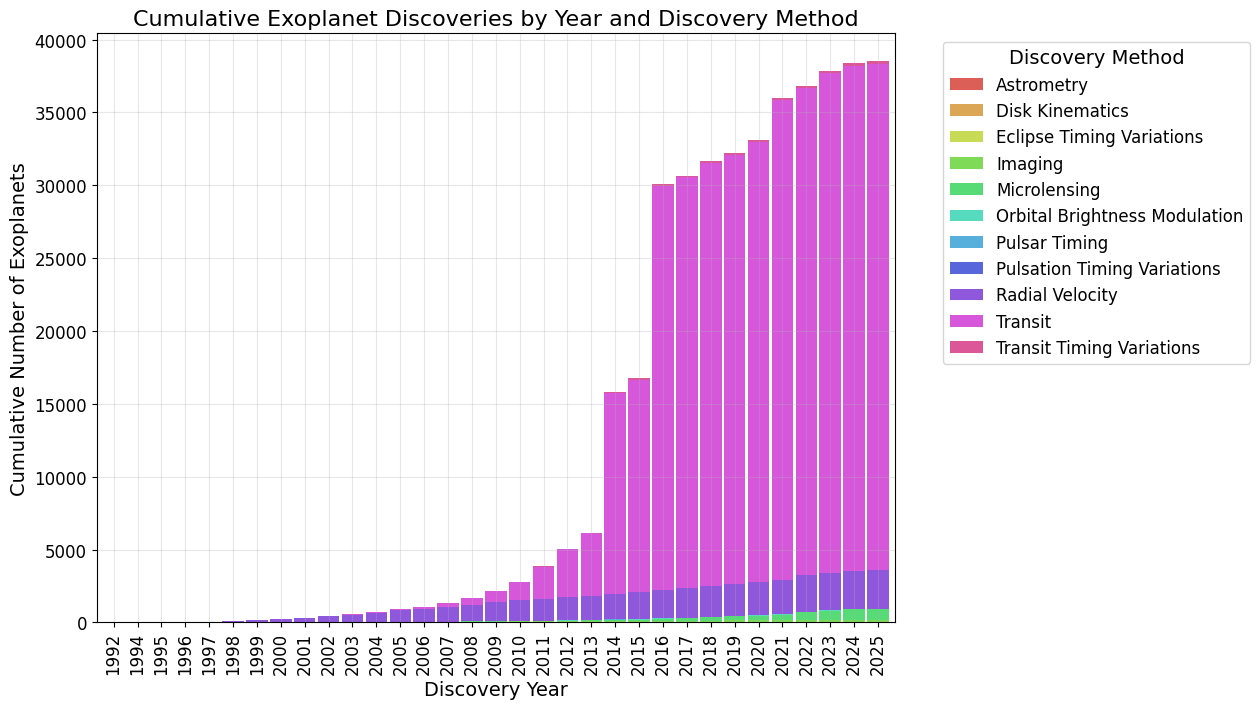

In [8]:
# since we are not looking at any characteristic quantity, there are a lot more samples for when an exoplanet was discovered.

# Calculate cumulative, stacked frequency histogram by discovery year and method
# Calculate yearly counts by discovery method
year_method_counts = df.groupby(['disc_year', 'discoverymethod']).size().unstack(fill_value=0)

# Calculate cumulative counts over years for each method
cumulative_counts = year_method_counts.cumsum()

hsl_palette = sns.color_palette("hls", len(cumulative_counts.columns))

cumulative_counts.plot(
    kind="bar",
    stacked=True,
    color=hsl_palette,
    width=0.9,
    edgecolor="none"
)

plt.title("Cumulative Exoplanet Discoveries by Year and Discovery Method")
plt.xlabel("Discovery Year")
plt.ylabel("Cumulative Number of Exoplanets")
plt.legend(title="Discovery Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()